# Quick start
## Install

Clone and install
```bash
git clone https://gitlab.windenergy.dtu.dk/TOPFARM/cuttingedge/pywake/fuga/PyFuga.git
cd PyFuga
pip install -e .
```

or install directly from gitlab

```bash
pip install git+https://gitlab.windenergy.dtu.dk/TOPFARM/cuttingedge/pywake/fuga/PyFuga.git
```

## Make luts

The function `get_luts` takes care of the whole process from input over preLUTs and fourierLUTs to the final LUTs that can be used in PyWake.

PreLUTs and fourierLUTs are loaded from files if present and otherwise generated and saved as netcdf files.

In [1]:
from pyfuga import get_luts

In [34]:
luts = get_luts(
    folder = 'luts', # Path where all files (intermediate and final) are stored
    zeta0=0, # Stability parameter
    nkz0=8, # Number of kz0 per decade. Total number of kz0 = 9 * nkz0 - (nkz0-1)
    nbeta=32, # Number of beta angles. Total number of beta angles = nbeta + 1
    diameter=80, # Wind turbine diameter
    zhub=70, # Wind turbine hub height
    z0=0.00001, # Roughness length
    zi=400, # Inversion height
    zlow=70, # Lower height of output domain. If zlow=zhigh=zhub, the output will only contain one layer at the hub height
    zhigh=70, # Upper height of output domain. If zlow=zhigh=zhub, the output will only contain one layer at the hub height
    lut_vars=['UL'], # Output data can be any combination of ['UL', 'UT', 'VL', 'VT', 'WL', 'WT', 'PL', 'PT']
    nx=2048, # Number of points in LUT (U direction)
    ny=512, # Number of points in LUT (V direction). Note only one half of the domain is stored
    dx=None, dy=None, # Distance between points on the x and y axis
    jit=True, # If True (default), some slow functions are just-in-time compiled
    n_cpu=None # Number of CPUs for parallelization, None means all available CPUs
) 

Trafalgar: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 17.17it/s]


The `luts` folder now contains the following files:
```
.
├── luts 
    ├── preLUTs_Zeta0=0.00_8_32.nc
    ├── fLUTs_Zeta0=0.00_8_32_D80_zhub70_zi400_z0=0.00001000_z70.0_UL.nc
    └── LUTs_Zeta0=0.00_8_32_D80_zhub70_zi400_z0=0.00001000_z70.0_UL_nx2048_ny512_dx20.0_dy5.0.nc
```


In [35]:
luts

<xarray.Dataset>
Dimensions:    (z: 1, x: 2048, y: 256)
Coordinates:
  * x          (x) float64 -1.024e+04 -1.022e+04 ... 3.068e+04 3.07e+04
  * y          (y) float64 0.0 5.0 10.0 15.0 ... 1.265e+03 1.27e+03 1.275e+03
  * z          (z) int32 70
Data variables:
    UL         (z, x, y) float64 0.0003629 0.0003629 ... 0.0003742 0.000374
    diameter   float64 80.0
    hubheight  int32 70
    z0         float64 1e-05
Attributes:
    zi:       400
    ds:       0.05
    kzmax:    300
    zeta0:    0.0
    accgoal:  0.0001
    nkz0:     8
    nbeta:    32
    name:     LUTs_Zeta0=0.00_8_32_D80_zhub70_zi400_z0=0.00001000_z70.0_UL_nx...

### Hub height normalized deficit field

(-250.0, 1750.0, -2.5, 497.5)

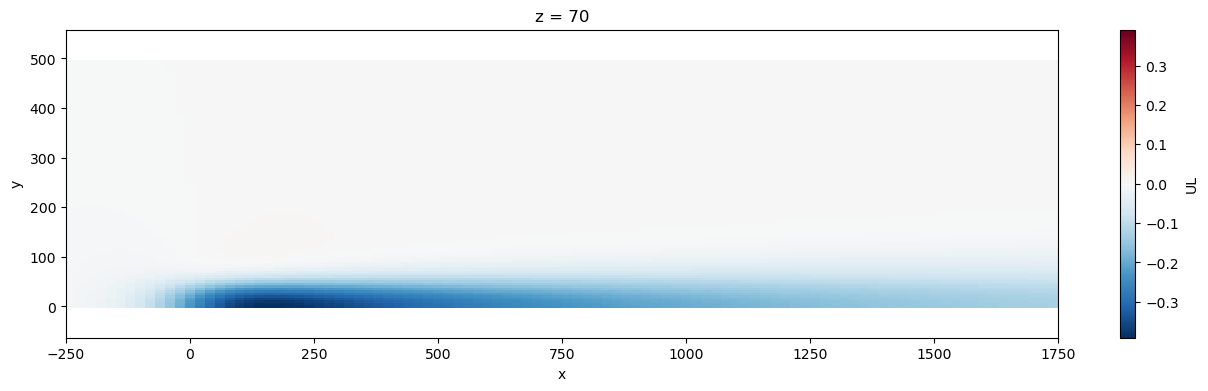

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,4))
luts.UL.squeeze()[500:600, :100].plot(x='x')
plt.axis('equal')

### Profile 5D downstream

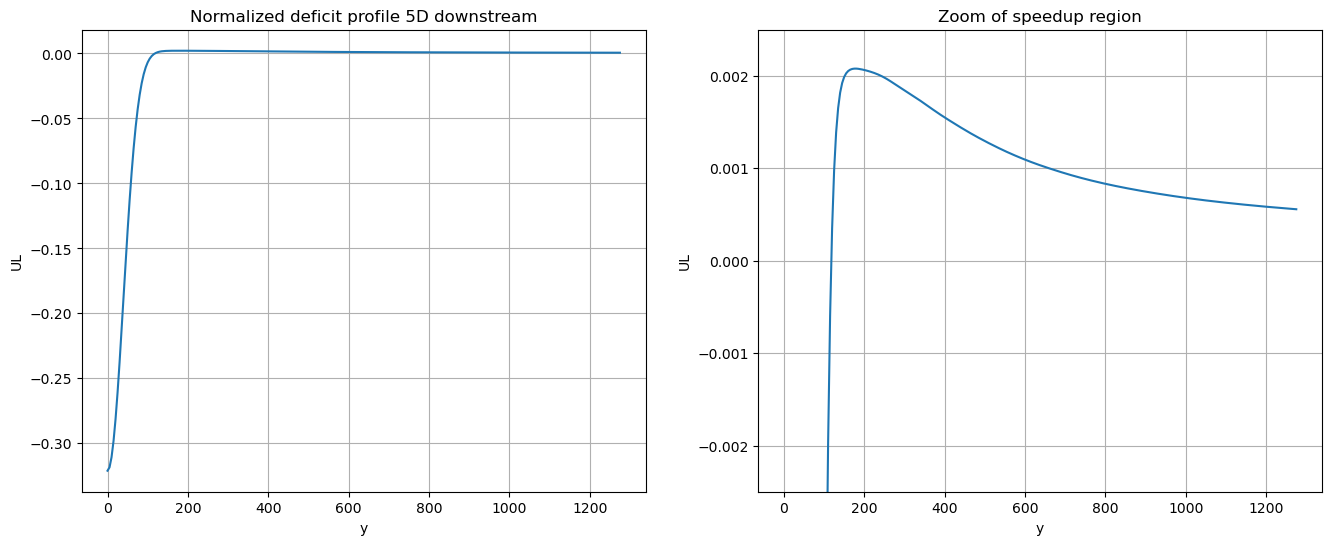

In [56]:
axes = plt.subplots(1,2, figsize=(16,6))[1]
for ax in axes:
    luts.UL.interp(x=80*5).plot(ax=ax)
    ax.grid()
axes[1].set_ylim([-0.0025,.0025])
axes[0].set_title("Normalized deficit profile 5D downstream");
axes[1].set_title("Zoom of speedup region");